# Notebook 1: Data Pipeline, Feature Engineering & Sliding Window Z-Score

Trong notebook này, chúng ta sẽ khám phá Module 1 của dự án **AI-Driven Market Neutral Portfolio Optimization**:
1. Tải dữ liệu OHLCV và chỉ số cơ bản cho rổ cổ phiếu **VN100** và **VN-Index** từ `vnstock` (với cơ chế tự động cache và mock fallback).
2. Xử lý dữ liệu khuyết thiếu (NaN) và đồng bộ ngày giao dịch.
3. Tính toán các tín hiệu **Momentum** (RSI, MACD, Lag returns), **Volatility** (ATR, Std), và **Fundamentals** (P/E, P/B, Market Cap).
4. Thực hiện chuẩn hóa **Sliding Window Z-score Normalization** để tuyệt đối không rò rỉ dữ liệu (0% Data Leakage).


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import Config
from src.data_pipeline import DataFetcher, DataCleaner, FeatureEngineer, DataPreprocessor

%matplotlib inline
sns.set_theme(style='whitegrid')


In [6]:
!pwd

/Users/phamtu/Desktop/factor/AI-Driven-Market-Neutral-Portfolio-Optimization/notebooks


## 1. Data Ingestion (Tải dữ liệu từ vnstock / Cache)


In [ ]:
fetcher = DataFetcher()
raw_data = fetcher.fetch_all_group()

print(f'Số lượng mã tải thành công: {len(raw_data)}')
print('Mẫu dữ liệu VNINDEX:')
raw_data['VNINDEX'].head()


[2026-08-02 17:48:19] [INFO] [DataFetcher]: fetching data symbol VNINDEX
[2026-08-02 17:48:19] [INFO] [DataFetcher]: Đang chờ 2.78s trước khi tải VNINDEX...
Số lượng mã tải thành công: 913
Mẫu dữ liệu VNINDEX:


KeyError: 'VNINDEX'

## 2. Data Cleaning & Alignment (Làm sạch & Đồng bộ lịch giao dịch)


In [3]:
cleaner = DataCleaner()
cleaned_data = cleaner.clean_and_align(raw_data)

print(f'Số lượng cổ phiếu đủ tiêu chuẩn sau làm sạch: {len(cleaned_data)-1}')
cleaned_data['VCB'].tail()


[2026-07-28 00:18:50] [INFO] [DataCleaner]: Aligning 50 symbols to benchmark (913 trading days)...
[2026-07-28 00:18:50] [INFO] [DataCleaner]: Alignment complete. Retained: 50 stocks. Dropped: 0.
Số lượng cổ phiếu đủ tiêu chuẩn sau làm sạch: 50


,date,open,high,low,close,volume,pe,pb,market_cap
908,2024-06-24,56.64,57.56,56.31,56.31,2153682,18.958408,1.953311,5.680886e+13
909,2024-06-25,56.44,57.10,56.31,56.31,1567779,14.148934,2.298678,3.013671e+13
910,2024-06-26,56.57,56.83,56.11,56.11,1709970,14.464174,3.081168,3.178683e+13
911,2024-06-27,56.11,56.64,56.11,56.11,1425080,22.458616,2.088030,1.222109e+13
912,2024-06-28,56.64,56.64,55.98,56.11,1114085,18.592575,2.265376,6.984167e+13


## 3. Feature Engineering (Tạo đặc trưng Kỹ thuật & Cơ bản)


In [4]:
feat_eng = FeatureEngineer()
feature_data = feat_eng.compute_all_features(cleaned_data)

print('Các đặc trưng được tạo ra cho mã VCB:')
feature_data['VCB'][['date', 'close', 'rsi_14', 'macd', 'atr_14_norm', 'std_20d', 'target_ret_1d']].tail(10)


[2026-07-28 00:18:56] [INFO] [FeatureEngineer]: Computing technical and fundamental features...
[2026-07-28 00:18:56] [INFO] [FeatureEngineer]: Feature engineering complete for 51 symbols.
Các đặc trưng được tạo ra cho mã VCB:


,date,close,rsi_14,macd,atr_14_norm,std_20d,target_ret_1d
903,2024-06-17,57.36,32.339791,-0.676380,0.014881,0.008421,0.000000
904,2024-06-18,57.36,35.457516,-0.689516,0.015043,0.008320,-0.005753
905,2024-06-19,57.03,38.339222,-0.718275,0.014879,0.008343,-0.006839
906,2024-06-20,56.64,42.300194,-0.763733,0.014326,0.008292,0.000000
907,2024-06-21,56.64,33.780760,-0.790645,0.013582,0.008187,-0.005826
908,2024-06-24,56.31,26.398209,-0.829044,0.014423,0.008203,0.000000
909,2024-06-25,56.31,25.396825,-0.849681,0.014676,0.008003,-0.003552
910,2024-06-26,56.11,22.098214,-0.872121,0.014894,0.007836,0.000000
911,2024-06-27,56.11,23.855421,-0.879763,0.014563,0.007429,0.000000
912,2024-06-28,56.11,25.916229,-0.875725,0.014321,0.006683,0.000000


## 4. Sliding Window Z-score Normalization (Chống rò rỉ dữ liệu)

Chuẩn hóa Z-score cho ngày $t$ chỉ sử dụng mean và std của các ngày trong quá khứ $[t-W, t-1]$, đảm bảo mô hình không học lén tương lai!


In [5]:
preprocessor = DataPreprocessor()
normalized_data = preprocessor.normalize_features(feature_data)

print('Dữ liệu sau khi chuẩn hóa Z-score (không rò rỉ):')
normalized_data['VCB'][['date', 'rsi_14', 'macd', 'atr_14_norm', 'pe', 'pb']].tail(10)


[2026-07-28 00:18:58] [INFO] [DataPreprocessor]: Applying Sliding Window Z-score Normalization (window=120 days)...
[2026-07-28 00:18:59] [INFO] [DataPreprocessor]: Normalization complete. No data leakage verified.
Dữ liệu sau khi chuẩn hóa Z-score (không rò rỉ):


,date,rsi_14,macd,atr_14_norm,pe,pb
903,2024-06-17,-0.985374,-1.224635,-0.615342,0.298048,-0.531046
904,2024-06-18,-0.813885,-1.245212,-0.572197,-0.924105,1.002739
905,2024-06-19,-0.655980,-1.290093,-0.626895,-1.068371,-0.919043
906,2024-06-20,-0.439291,-1.360048,-0.798940,-0.374230,-0.874124
907,2024-06-21,-0.953242,-1.403720,-1.029684,0.647728,0.382126
908,2024-06-24,-1.385481,-1.461777,-0.781334,0.342878,-0.574965
909,2024-06-25,-1.435988,-1.489864,-0.713514,-0.787283,-0.065981
910,2024-06-26,-1.611213,-1.517009,-0.658145,-0.719581,1.060175
911,2024-06-27,-1.493787,-1.519834,-0.771993,1.194052,-0.377804
912,2024-06-28,-1.370919,-1.508411,-0.845492,0.255902,-0.118912


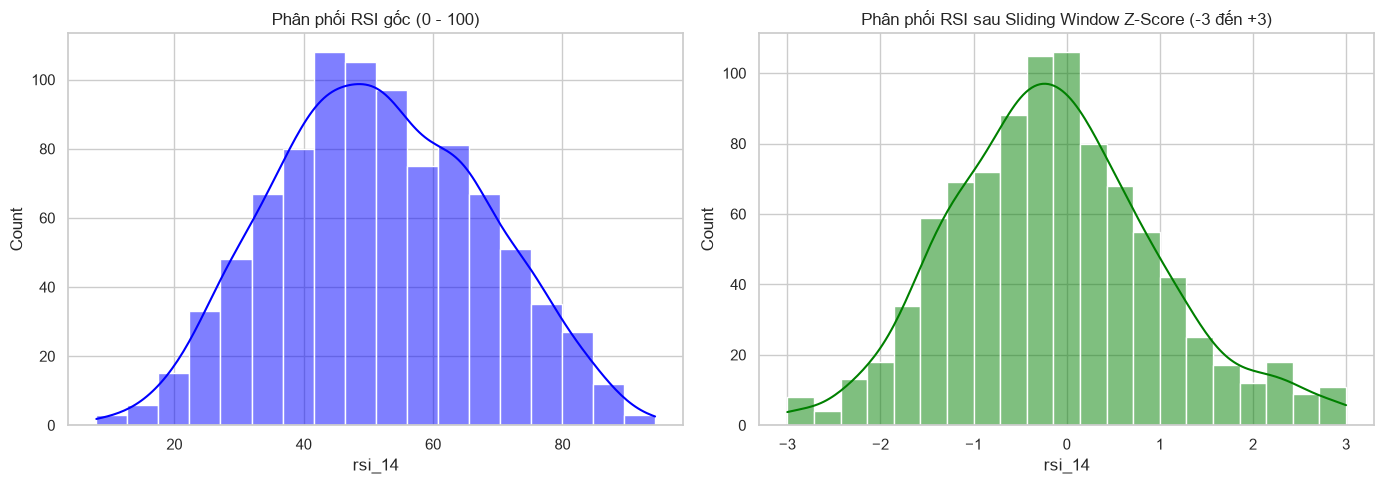

In [6]:
# Trực quan hóa phân phối đặc trưng trước và sau chuẩn hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(feature_data['VCB']['rsi_14'], ax=axes[0], kde=True, color='blue')
axes[0].set_title('Phân phối RSI gốc (0 - 100)')

sns.histplot(normalized_data['VCB']['rsi_14'], ax=axes[1], kde=True, color='green')
axes[1].set_title('Phân phối RSI sau Sliding Window Z-Score (-3 đến +3)')
plt.tight_layout()
plt.show()
